In [68]:
import numpy as np
import scipy.stats as stats
import scipy.special as special
import matplotlib.pyplot as plt

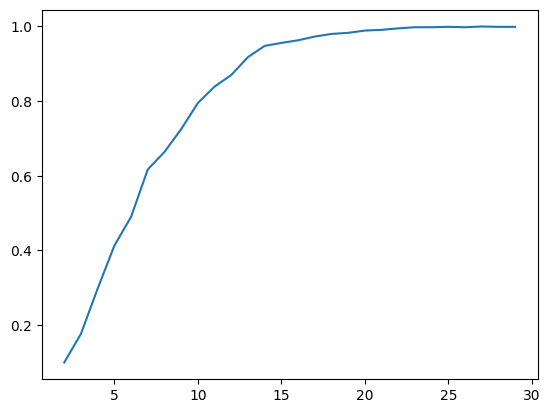

In [4]:
N = 1000
counts = []
ns = np.arange(2, 30)
for n in ns:
    count = 0
    popmean = 1.0
    rng = np.random.default_rng()
    for _ in range(N):
        x = rng.normal(size=n)
        stat, pvalue = stats.ttest_1samp(x, popmean)
        if pvalue < 0.05:
            count += 1
    counts.append(count)

plt.plot(ns, np.array(counts) / N)

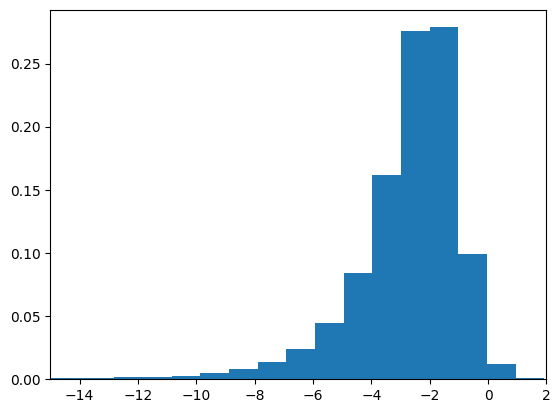

In [5]:
N = 10000
statistics = []
n = 5
popmean = 1.0
for _ in range(N):
    x = rng.normal(size=n)
    statistic, pvalue = stats.ttest_1samp(x, popmean)
    statistics.append(statistic)
statistics = np.array(statistics)
plt.hist(statistics, bins=50, density=True)
plt.xlim(-15, 2)
plt.show()

Suppose $x_i\sim N(\mu_1, \sigma^2)$. Set
$$
t = \frac{\sqrt{n}(\bar{x} - \mu_0)}{s}.
$$

Then
$$
\begin{aligned}
t &= \frac{\dfrac{\sqrt{n}}{\sigma}(\bar{x} - \mu_0)}{\dfrac{s}{\sigma}}\\
&= \frac{\dfrac{\sqrt{n}}{\sigma}(\bar{x} - \mu_1) + \dfrac{\sqrt{n}}{\sigma}(\mu_1 - \mu_0)}{\dfrac{s}{\sigma}}\\
&= \frac{Z + \dfrac{\sqrt{n}\delta}{\sigma}}{\sqrt{\dfrac{V}{n-1}}},
\end{aligned}
$$
where
$$
Z = \dfrac{\sqrt{n}}{\sigma}(\bar{x} - \mu_1),\qquad
\delta = \mu_1 - \mu_0,\qquad\text{and}\qquad
V = (n-1)\frac{s^2}{\sigma^2}
$$

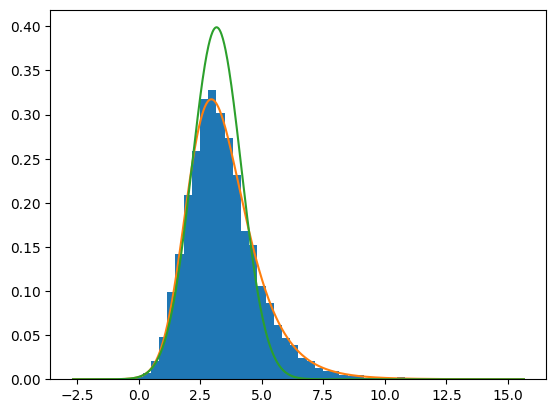

In [21]:
mu0 = 0
mu1 = 1
sigma = 1
n = 10
rng = np.random.default_rng()
statistics = []
for _ in range(10000):
    x = rng.normal(mu1, size=n)
    statistic, pvalue = stats.ttest_1samp(x, popmean=mu0)
    statistics.append(statistic)
plt.hist(statistics, bins=50, density=True)
grid = np.linspace(*plt.xlim(), 1000)
plt.plot(grid, stats.nct.pdf(grid, df=n - 1, nc=np.sqrt(n)))
plt.plot(grid, stats.norm.pdf(grid, loc=np.sqrt(n)))
plt.show()

In [28]:
a = stats.t.ppf(0.025, df=n)
b = stats.t.ppf(1 - 0.025, df=n)
assert np.isclose(stats.t.cdf(b, df=n) - stats.t.cdf(a, df=n), 0.95)

### One-sample $z$-test &mdash; sample size formula

Suppose we have data
$$X_0,\ldots,X_{n-1}\sim N(\mu, \sigma^2)$$
and that we want to test
$$
H_0:\mu=\mu_0\qquad\text{versus}\qquad\mu=\mu_1.
$$

Assume that $\sigma$ is known and that $\mu_1 > \mu_0$.

We use the test statistic
$$
Z_n = \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}}.
$$

Under $H_0$, $Z\sim N(0, 1)$.

For the two-sided, one-sample $z$-test to have level $\alpha$, we need $c$ such that
$$
P(|Z_n| > c\mid H_0) = \alpha.
$$
We solve
$$
\begin{aligned}
\alpha &= P(|Z_n| > c\mid H_0)\\
&= 2P(Z_n > c\mid H_0)\\
&= 2(1 - P(Z_n\leq c))\\
&= 2(1 - \operatorname{cdf}(c))
\end{aligned}
$$
in terms of the inverse function $\operatorname{ppf}$ of $\operatorname{cdf}$:
$$
c = \operatorname{ppf}\left(1 - \frac\alpha2\right) =: z_{1 - \alpha/2}
$$
Thus, the test that rejects $H_0$ for $|Z_n| > z_{1 - \alpha/2}$ has level $\alpha$.

We have:
$$
\begin{aligned}
Z_n &= \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}}\\
&= \frac{\bar{X} - \mu_1}{\sigma/\sqrt{n}} + \frac{\mu_1 - \mu_0}{\sigma/\sqrt{n}}\\
&= Y_n + d\sqrt{n},
\end{aligned}
$$
where
$$
Y_n = \frac{\bar{X} - \mu_1}{\sigma/\sqrt{n}}
\qquad\text{and}\qquad
d = \frac{\mu_1 - \mu_0}{\sigma}.
$$
Under $H_1$, $Y_n\sim N(0, 1)$.

For the test that rejects $H_0$ when $|Z_n| > z_{1 - \alpha/2}$ to have power $1-\beta$, we need
$$
\begin{aligned}
1 - \beta &= P(|Z_n| > z_{1 - \alpha/2}\mid H_1)\\
&= P(Z_n < -z_{1 - \alpha/2}\mid H_1) + P(Z_n > z_{1 - \alpha/2}\mid H_1)\\
&= P(Y_n + d\sqrt{n} < -z_{1 - \alpha/2}\mid H_1) + P(Y_n + d\sqrt{n} > z_{1 - \alpha/2}\mid H_1)\\
&= P(Y_n < -z_{1 - \alpha/2} - d\sqrt{n}\mid H_1) + P(Y_n > z_{1 - \alpha/2} - d\sqrt{n}\mid H_1)\\
&= \operatorname{cdf}(-z_{1 - \alpha/2} - d\sqrt{n}) + 1 - \operatorname{cdf}(z_{1 - \alpha/2} - d\sqrt{n}).
\end{aligned}
$$
Now $d > 0$ as $\mu_1 > \mu_0$. Typically, $-z_{1 - \alpha/2} - d\sqrt{n}$ is sufficiently small so that $\operatorname{cdf}(-z_{1 - \alpha/2} - d\sqrt{n})$ is negligible, in which case
$$
  \beta\approx \operatorname{cdf}(z_{1 - \alpha/2} - d\sqrt{n}).
$$

$$
z_\beta = z_{1 - \alpha/2} - d\sqrt{n}
$$
Solving this equation for $n$ gives
$$
n \approx \left(\frac{z_{1 - \alpha/2} - z_{\beta}}{d}\right)^2.
$$

#### Example

Suppose $\sigma=1$. How large must $n$ be so that the test of
$$
H_0:\mu = 0\qquad\text{versus}\qquad
H_1:\mu = 1
$$
has significance level $\alpha=0.05$ and power $1-\beta=0.9$?

##### Solution

$$
d = \frac{\mu_1 - \mu_0}{\sigma} = \frac{1 - 0}{1} = 1
$$

$$
n \approx \left(\frac{z_{0.975} + z_{0.1}}{1}\right)^2
$$

In [ ]:
alpha = 0.05
beta = 0.1
za = stats.norm().ppf(1 - alpha / 2)
zb = stats.norm.ppf(0.1)
n = int(np.ceil((za - zb) ** 2))
print(f"{n=}")

mu0 = 0
mu1 = 1
sigma = 1
N = 1000
zs = np.zeros(N)
for i in range(N):
    x = stats.norm(loc=mu1, scale=sigma).rvs(n)
    xbar = x.mean()
    z = (xbar - mu0) / (sigma / np.sqrt(n))
    zs[i] = z

np.mean(zs > za)  # should be approximately 0.9

n=11


np.float64(0.901)

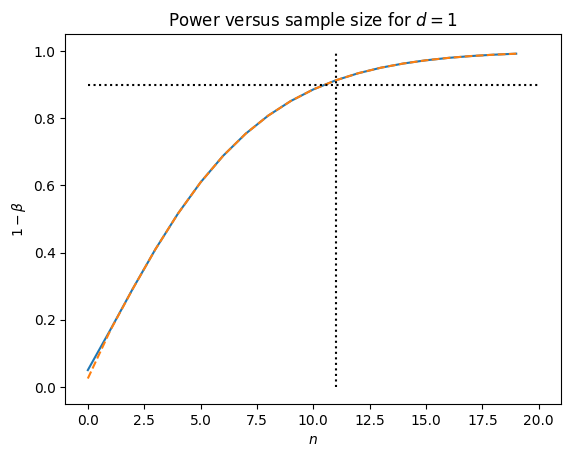

In [ ]:
n = np.arange(20)
one_minus_beta = (
    stats.norm().cdf(-za - np.sqrt(n)) + 1 - stats.norm().cdf(za - np.sqrt(n))
)
plt.plot(n, one_minus_beta)
plt.plot(n, 1 - stats.norm().cdf(za - np.sqrt(n)), "--")
plt.plot([11, 11], [0, 1], "k:")
plt.plot([0, 20], [0.9, 0.9], "k:")
plt.xlabel("$n$")
plt.ylabel("$1 - \\beta$")
plt.title("Power versus sample size for $d=1$")
plt.show()

In [ ]:
n = (za - zb) ** 2
one_minus_beta = 1 - stats.norm().cdf(za - np.sqrt(n))
one_minus_beta

np.float64(0.8999999999999999)

#### Rice, Chapter 9, Exercise 1
A coin is thrown independently 10 times to test the hypothesis that the probability of heads is $\frac12$
versus the alternative that the probability is not $\frac12$.
The test rejects if either 0 or 10 heads are observed

1. What is the significance level of the test?

2. If in fact the probability of heads is 0.1, what is the power of the test?

$$
P(\text{reject $H_0$}\mid H_0) = P(X = 0\;\text{or}\; X = 10\mid \tfrac12 ) = 0.002
$$

In [ ]:
0.1**0 * (1 - 0.1) ** 10

0.3486784401000001

In [ ]:
0.1**10 * (1 - 0.1) ** 0

1.0000000000000006e-10

Parameter space: $\Theta = \Theta_0\sqcup\Theta_1$

Rejection region: $R$, typically defined by a test statistic

Power function: $\beta(\theta) = P(X\in R\mid \theta)$

We want $\beta(\theta)\approx 0$ for $\theta\in\Theta_0$ and $\beta(\theta)\approx 1$ for $\theta\in\Theta_1$.

Suppose
$$
\Theta_0 = (-\infty, \theta_0],\qquad
\Theta_1 = (\theta_0, \infty]
$$

$$
R = \{\bar{X} > c\}
$$

$$
\beta(\theta) = P(\bar{X} > c\mid\theta)
= P\left(\frac{\bar{X} - \theta}{\sigma/\sqrt{n}} > \frac{c - \theta}{\sigma/\sqrt{n}}\right)
= \operatorname{sf}\left(\frac{c - \theta}{\sigma/\sqrt{n}}\right)
$$

I suspect that a coin is biased in favor of heads.

Test the null hypothesis
$$
H_0:\theta = 0.5\qquad\text{versus}\qquad H_1: \theta = 0.7
$$

$$
X\sim \operatorname{Binomial}(10, \theta)
$$

Rejection region:
$$
R_c = \{X \geq c\}
$$

$$
P(X \geq c\mid \theta=0.5 ) = \sum_{x=c}^{10}P(X=x\mid\theta=0.5)
= \sum_{x=c}^{10}\binom{10}{x}0.5^n
$$

In [ ]:
for c in np.arange(11):
    x = np.arange(c, 11)
    print(special.binom(10, x).sum() / 2**10)

1.0
0.9990234375
0.9892578125
0.9453125
0.828125
0.623046875
0.376953125
0.171875
0.0546875
0.0107421875
0.0009765625


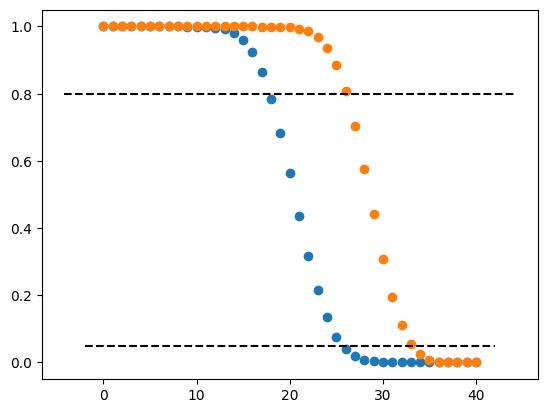

In [ ]:
n = 40
theta0 = 0.5
theta1 = 0.7

x = np.arange(n + 1)

u = special.binom(n, x) * theta0**x * (1 - theta0) ** (n - x)
u = np.cumsum(u[::-1])[::-1]

v = special.binom(n, x) * theta1**x * (1 - theta1) ** (n - x)
v = np.cumsum(v[::-1])[::-1]

plt.plot(u, "o")
plt.plot(v, "o")
plt.plot(plt.xlim(), [0.05, 0.05], "k--")
plt.plot(plt.xlim(), [0.8, 0.8], "k--")

In [ ]:
for m, n in zip(u, v):
    print(m, n)
    if m < 0.05:
        break

1.0 1.0
0.9999999999990905 1.0
0.9999999999627107 1.0
0.9999999992533048 1.0
0.9999999902674972 0.9999999999999999
0.9999999071487764 0.9999999999999966
0.9999993086939867 0.9999999999999413
0.9999958177077133 0.9999999999991882
0.9999788614886711 0.9999999999906529
0.9999089170851221 0.9999999999085011
0.9996602258725034 0.9999999992269452
0.9988892831133853 0.9999999942970237
0.9967867119521543 0.9999999629247961
0.9917054983125126 0.9999997860202905
0.9807613458578999 0.9999988969617496
0.9596547661240038 0.9999948961983157
0.923070027918584 0.9999787153328723
0.8659063744726154 0.9999197225942763
0.7852047460783069 0.999725393573019
0.6820859986855794 0.9991460051948261
0.5626853438097896 0.9975806401028663
0.43731465619021037 0.9937454956275649
0.3179140013144206 0.9852229523491173
0.21479525392169307 0.9680487363486091
0.13409362552738457 0.9366871245215943
0.07692997208141605 0.8848533494186115
0.0403452338759962 0.8074482452648237


In [ ]:
1 / 6

0.16666666666666666

You roll a die 30 times and it comes up six eight times. Can you conclude the die is loaded at the 0.05 significance level?

$$
P(Y\geq 8\mid p=1/6)
$$

In [ ]:
stats.binom.pmf(np.arange(8, 31), n=30, p=1 / 6).sum()

np.float64(0.11368680121359272)

In [ ]:
1 - stats.binom.cdf(7, n=30, p=1 / 6)

np.float64(0.11368680121359265)

In [ ]:
stats.binom.sf(7, n=30, p=1 / 6)

np.float64(0.1136868012135926)

Find $c$ and $n$ such that
$$
P(Y > c\mid p=1/6)\leq 0.05
\qquad\text{and}\qquad
P(Y > c\mid p=1/4)\geq 0.9
$$

In [ ]:
n = 210
c = np.arange(n)
i = np.argmax(stats.binom.sf(c, n=n, p=1 / 6) < 0.05)
print(i, c[i], stats.binom.sf(i, n=n, p=1 / 6))
stats.binom.sf(i, n=n, p=1 / 4)

44 44 0.04256811582772523


np.float64(0.9004785559643127)

In [ ]:
np.mean(stats.binom(n=210, p=1 / 6).rvs(1_000_000) > 44)

np.float64(0.042477)

In [ ]:
np.mean(stats.binom(n=210, p=1 / 4).rvs(1_000_000) > 44)

np.float64(0.900619)

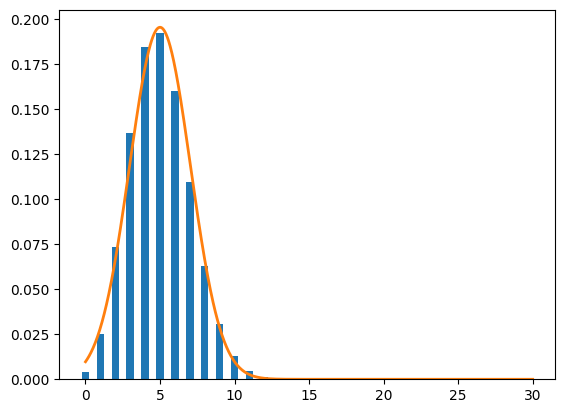

In [ ]:
n = 30
p = 1 / 6
grid = np.arange(0, n)
plt.bar(grid, stats.binom.pmf(grid, n=n, p=p), width=0.5)
grid = np.linspace(0, n, 1000)
plt.plot(
    grid, stats.norm.pdf(grid, loc=n * p, scale=np.sqrt(n * p * (1 - p))), "C1", lw=2
)

In [ ]:
stats.norm.sf(8, loc=n * p, scale=np.sqrt(n * p * (1 - p)))

np.float64(0.0708223451475684)

### Two-sample $z$-test &mdash; sample size formula

Suppose we have data
$$
X_0,\ldots,X_{n-1}\sim N(\mu_0, \sigma^2),\qquad
Y_0,\ldots,Y_{n-1}\sim N(\mu_1, \sigma^2).
$$
and that we want to test
$$
H_0:\mu_1-\mu_0 = 0\qquad\text{versus}\qquad\mu_1 - \mu_0 = \delta > 0.
$$

Assume that $\sigma$ is known and that $\delta > 0$.

We use the test statistic
$$
Z = \frac{\bar{X} - \bar{Y}}{s_p\sqrt{\frac{2}{n}}}.
$$

Under $H_0$, $Z\sim N(0, 1)$.

For the two-sided, one-sample $z$-test to have level $\alpha$, we need $c$ such that
$$
P(|Z_n| > c\mid H_0) = \alpha.
$$
We solve
$$
\begin{aligned}
\alpha &= P(|Z_n| > c\mid H_0)\\
&= 2P(Z_n > c\mid H_0)\\
&= 2(1 - P(Z_n\leq c))\\
&= 2(1 - \operatorname{cdf}(c))
\end{aligned}
$$
in terms of the inverse function $\operatorname{ppf}$ of $\operatorname{cdf}$:
$$
c = \operatorname{ppf}\left(1 - \frac\alpha2\right) =: z_{1 - \alpha/2}
$$
Thus, the test that rejects $H_0$ for $|Z_n| > t_{\alpha/2}$ has level $\alpha$.

We have:
$$
\begin{aligned}
Z_n &= \frac{\bar{X} - \mu_0}{\sigma/\sqrt{n}}\\
&= \frac{\bar{X} - \mu_1}{\sigma/\sqrt{n}} + \frac{\mu_1 - \mu_0}{\sigma/\sqrt{n}}\\
&= Y_n + d\sqrt{n},
\end{aligned}
$$
where
$$
Y_n = \frac{\bar{X} - \mu_1}{\sigma/\sqrt{n}}
\qquad\text{and}\qquad
d = \frac{\mu_1 - \mu_0}{\sigma}.
$$
Under $H_1$, $Y_n\sim N(0, 1)$.

For the test that rejects $H_0$ when $|Z_n| > z_{1 - \alpha/2}$ to have power $1-\beta$, we need
$$
\begin{aligned}
1 - \beta &= P(|Z_n| > z_{1 - \alpha/2}\mid H_1)\\
&= P(Z_n < -z_{1 - \alpha/2}\mid H_1) + P(Z_n > z_{1 - \alpha/2}\mid H_1)\\
&= P(Y_n + d\sqrt{n} < -z_{1 - \alpha/2}\mid H_1) + P(Y_n + d\sqrt{n} > z_{1 - \alpha/2}\mid H_1)\\
&= P(Y_n < -z_{1 - \alpha/2} - d\sqrt{n}\mid H_1) + P(Y_n > z_{1 - \alpha/2} - d\sqrt{n}\mid H_1)\\
&= \operatorname{cdf}(-z_{1 - \alpha/2} - d\sqrt{n}) + 1 - \operatorname{cdf}(z_{1 - \alpha/2} - d\sqrt{n}).
\end{aligned}
$$
Now $d > 0$ as $\mu_1 > \mu_0$. Typically, $-z_{1 - \alpha/2} - d\sqrt{n}$ is sufficiently small so that $\operatorname{cdf}(-z_{1 - \alpha/2} - d\sqrt{n})$ is negligible, in which case
$$
  \beta\approx \operatorname{cdf}(z_{1 - \alpha/2} - d\sqrt{n}).
$$

$$
z_\beta = z_{1 - \alpha/2} - d\sqrt{n}
$$
Solving this equation for $n$ gives
$$
n \approx \left(\frac{z_{1 - \alpha/2} - z_{\beta}}{d}\right)^2.
$$